## Modèle 3 — Régression : Prévision des revenus futurs

Objectif :
Prédire la variable `total_payments` à partir :
- du comportement étudiant
- des caractéristiques des packages

Importation des bibliothèques

In [18]:
%pip install seaborn openpyxl scikit-learn pandas --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

2.Chargement des données

In [19]:

from google.colab import files
uploaded = files.upload()

import pandas as pd
import os


print("Fichiers présents :", os.listdir())


df = pd.read_excel('dataset_clean (1).xlsx')


df = df.drop_duplicates(subset='student_id')


print(f'Nombre d’étudiants : {df.shape[0]}')
print(f'Nombre de colonnes : {df.shape[1]}')


df.head()

Saving dataset_clean (1).xlsx to dataset_clean (1) (1).xlsx
Fichiers présents : ['.config', 'dataset_clean (1).xlsx', 'dataset_clean (1) (1).xlsx', 'sample_data']
Nombre d’étudiants : 3000
Nombre de colonnes : 28


,student_id,age,gender,english_level,attendance_rate,avg_test_score,engagement_score,login_frequency_per_week,time_spent_hours_per_week,package_type,...,registration_channel,days_since_last_login,course_completion_rate,assignment_submission_rate,video_watch_percentage,discount_used,payment_delay_days,upgrade_history,churn,lifetime_value
0,1,54,Female,Beginner,0.94,75.98,0.57,1,11.79,Basic,...,Facebook,20,0.41,0.57,0.61,0,24,4,0,1646
1,2,44,Female,Intermediate,0.91,50.65,0.97,12,19.98,Standard,...,Facebook,15,0.59,0.78,0.82,0,0,4,0,1754
2,3,30,Male,Intermediate,0.65,58.22,0.49,2,19.11,Basic,...,Facebook,14,0.88,0.51,0.69,0,9,0,0,928
3,4,23,Male,Intermediate,0.47,60.21,0.95,11,13.45,Standard,...,Referral,53,0.76,0.58,0.74,0,24,2,0,1356
4,5,36,Male,Beginner,0.45,74.07,0.11,11,9.83,Standard,...,Instagram,56,0.58,0.69,0.92,0,29,3,1,1098


3.Exploration des données

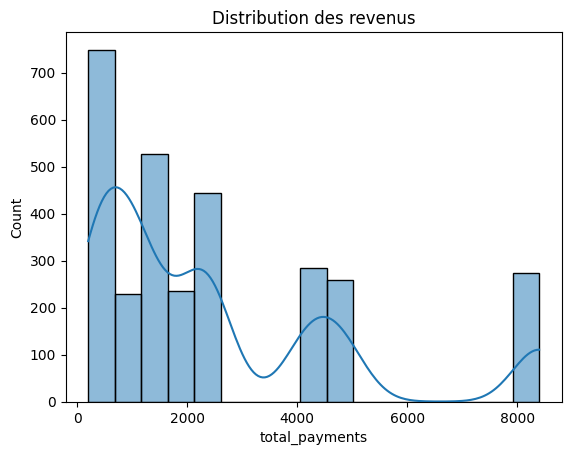

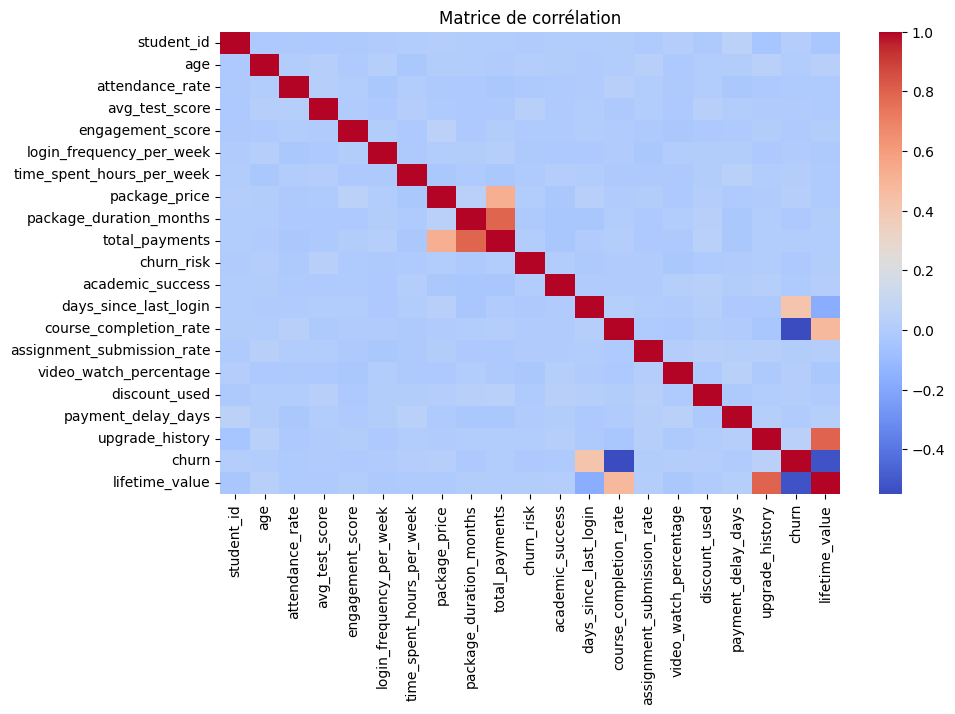

In [20]:
plt.figure()
sns.histplot(df['total_payments'], kde=True)
plt.title("Distribution des revenus")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

4.Préparation des données


In [21]:
target = 'total_payments'

X = df.drop(columns=[target, 'student_id'])
y = df[target]

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5 : Train / Test Split


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Modèle 1 : Linear Regression

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2 LR :", r2_score(y_test, y_pred_lr))
print("RMSE LR :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 LR : 0.8734205601120397
RMSE LR : 876.1706012107703


Modèle 2 : Decision Tree

In [24]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 DT :", r2_score(y_test, y_pred_dt))
print("RMSE DT :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

R2 DT : 1.0
RMSE DT : 0.0


Modèle 3 : Random Forest

In [25]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)
print("R2 RF :", r2_score(y_test, y_pred_rf))
print("RMSE RF :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV Score: 1.0
R2 RF : 1.0
RMSE RF : 0.0


Modèle 4 : Gradient Boosting

In [26]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print("Best GB Params:", grid_gb.best_params_)
print("Best GB CV Score:", grid_gb.best_score_)
print("R2 GB :", r2_score(y_test, y_pred_gb))
print("RMSE GB :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best GB CV Score: 1.0
R2 GB : 1.0
RMSE GB : 1.7374707172661562e-06


6 : Comparaison des modèles

In [28]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest (Tuned)", "Gradient Boosting (Tuned)"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,R2,RMSE
1,Decision Tree,1.000000,0.000000
2,Random Forest (Tuned),1.000000,0.000000
3,Gradient Boosting (Tuned),1.000000,0.000002
0,Linear Regression,0.873421,876.170601


7 : Visualisation du meilleur modèle

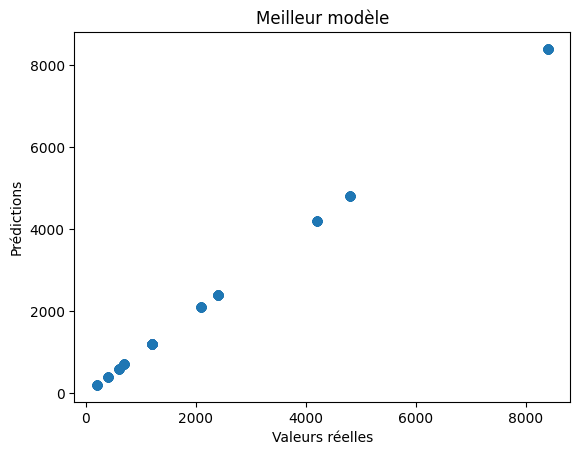

In [ ]:
import matplotlib.pyplot as plt
import joblib

# comparer les modèles
rf_score = grid_rf.best_score_
gb_score = grid_gb.best_score_

if rf_score >= gb_score:
    best_model = grid_rf.best_estimator_
    print("Random Forest sélectionné")
else:
    best_model = grid_gb.best_estimator_
    print("Gradient Boosting sélectionné")

# prédictions
best_pred = best_model.predict(X_test)

# plot
plt.scatter(y_test, best_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Meilleur modèle")
plt.show()

# sauvegarde
joblib.dump(best_model, "best_model.pkl")

Conclusion:Les modèles de régression ont été testés pour prédire les revenus.

Les résultats montrent que :
- Random Forest et Gradient Boosting donnent les meilleures performances
- les relations entre variables sont non linéaires

Le modèle final permet une bonne estimation des revenus futurs.